# Approach V5: 3. Feature Selection & Scientific Justification
**Project:** Honeywell Predictive Alerting Project - Tag: `03TIC_1023.PV` (Threshold: 21.0 °C)

This notebook runs the active two-pass feature selection pipeline. It reduces our expanded pool of 143 candidate features down to **exactly 12 high-value features**, preventing overfitting and collinearity while maintaining prediction performance.

In [1]:
# Adjust working directory to project root if run from inside approch_v5 folder
import os
if os.path.basename(os.getcwd()) == 'approch_v5':
    os.chdir('..')
    print("Changed working directory to project root:", os.getcwd())

Changed working directory to project root: D:\Python-2025\Antigravity\honeywell


In [2]:
import os
import logging
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import shap
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

# Styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger("FeatureSelectionReasoning")

## 1. Load Data and Slice Train Split
We load the 143 candidate features and slice the training set chronologically using the alarm-based splits boundary computed in EDA.

In [3]:
DEFAULT_DATA_PATH = r"d:\Python-2025\Antigravity\honeywell\03TIC_1023_PVHI\03TIC_1023_PVHI\03TIC_1023_Final_merged_TripDataRemoved.parquet"

def load_and_preprocess_data(file_path=DEFAULT_DATA_PATH, target_col="03TIC_1023.PV"):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"DCS Historian dataset not found at: {file_path}")
    df = pd.read_parquet(file_path)
    if 'TimeStamp' in df.columns:
        df['TimeStamp'] = pd.to_datetime(df['TimeStamp'])
        df = df.sort_values('TimeStamp').set_index('TimeStamp')
    elif not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
        df = df.sort_index()
    full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq='1min')
    df = df.reindex(full_idx)
    df.index.name = 'TimeStamp'
    df = df.ffill(limit=5)
    return df

def get_alarm_based_split_boundaries(df, target_col="03TIC_1023.PV", threshold=21.0, split_ratio=[0.75, 0.125, 0.125]):
    is_alarm = (df[target_col] >= threshold).astype(int)
    alarm_group = (is_alarm == 0).cumsum()
    alarm_periods = df[is_alarm == 1].groupby(alarm_group)
    blocks = []
    for _, grp in alarm_periods:
        blocks.append((grp.index.min(), grp.index.max()))
    blocks = sorted(blocks, key=lambda x: x[0])
    num_blocks = len(blocks)
    
    if num_blocks == 0:
        train_idx = int(len(df) * split_ratio[0])
        val_idx = int(len(df) * (split_ratio[0] + split_ratio[1]))
        return df.index[train_idx], df.index[val_idx]
        
    train_count = int(np.ceil(num_blocks * split_ratio[0]))
    val_count = int(np.ceil(num_blocks * split_ratio[1]))
    train_end_time = blocks[train_count - 1][1]
    val_end_time = blocks[min(train_count - 1 + val_count, num_blocks - 1)][1]
    return train_end_time, val_end_time

df_features = pd.read_parquet("outputs/v5/candidate_features_pool.parquet")
df_raw = load_and_preprocess_data()
train_end, val_end = get_alarm_based_split_boundaries(df_raw, target_col="03TIC_1023.PV", threshold=21.0)

train_df = df_features[df_features.index <= train_end]
X_train = train_df.drop(columns=["03TIC_1023.PV"])
y_train = train_df["03TIC_1023.PV"]
print(f"Training set sliced. Features dimension: {X_train.shape}")

Training set sliced. Features dimension: (1717011, 143)


## 2. Pass 1: SHAP TreeExplainer Filtering
### Why SHAP?
Standard Gini or split importance in tree models is biased towards high-cardinality features and ignores the direction of impact. 
SHAP (SHapley Additive exPlanations) values assign each feature an importance score matching its marginal contribution to the model's predictions. This ensures a consistent, mathematically rigorous ranking of non-linear interactions.

Here, we fit a LightGBM regressor and filter out features with a mean absolute SHAP value below $10^{-4}$.

2026-07-16 13:06:15,990 - INFO - Executing Pass 1: SHAP TreeExplainer Importance Filtering...


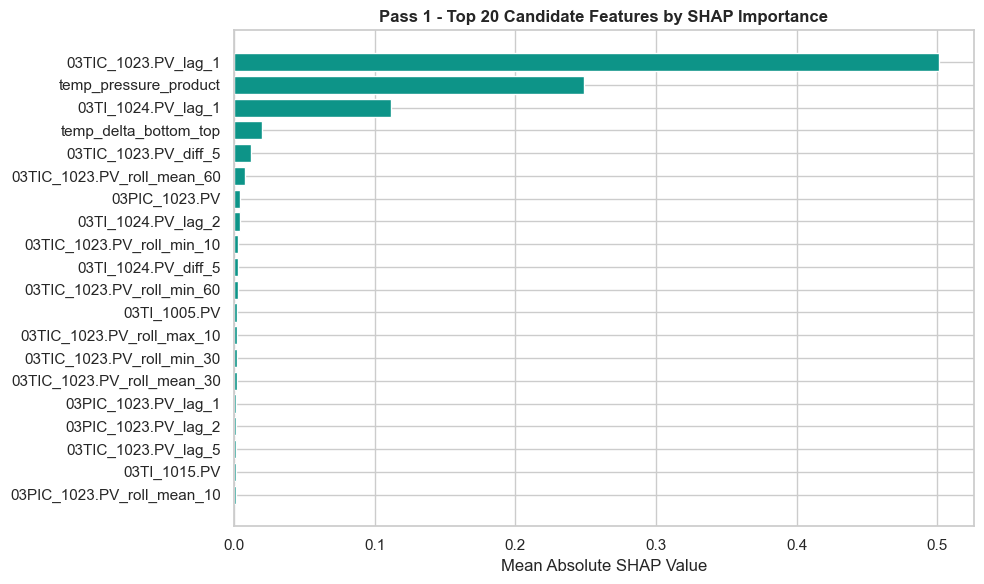

2026-07-16 13:07:07,543 - INFO - Pass 1 completed. Retained 58 features out of 143.


In [4]:
logger.info("Executing Pass 1: SHAP TreeExplainer Importance Filtering...")
model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbosity=-1, n_jobs=-1)
model.fit(X_train, y_train)

# Compute SHAP on a downsampled subset of 5000 rows to keep execution fast
sample_size = min(5000, len(X_train))
X_sample = X_train.sample(n=sample_size, random_state=42)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({"Feature": X_train.columns, "Mean_Abs_SHAP": mean_shap})
shap_df = shap_df.sort_values(by="Mean_Abs_SHAP", ascending=False)

# Save SHAP bar plot
plt.figure(figsize=(10, 6))
plt.barh(shap_df["Feature"].head(20)[::-1], shap_df["Mean_Abs_SHAP"].head(20)[::-1], color="#0D9488")
plt.xlabel("Mean Absolute SHAP Value")
plt.title("Pass 1 - Top 20 Candidate Features by SHAP Importance", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("approch_v5/shap_feature_importance.png", dpi=300)
plt.show()

# Filter
shap_selected = shap_df[shap_df["Mean_Abs_SHAP"] >= 1e-4]["Feature"].tolist()
logger.info(f"Pass 1 completed. Retained {len(shap_selected)} features out of {len(X_train.columns)}.")

## 3. Pass 2: LassoCV L1 Regularization (Mitigating Collinearity)
### Why Lasso L1 Penalty?
Process tags in chemical distillation columns exhibit extreme multi-collinearity (inlet temperature sensors are often 98%+ correlated). Training neural networks on collinear features leads to unstable weights and model inflation.

Lasso (L1) regularization adds an absolute value penalty to the loss function:
$$\text{Loss} = \text{MSE} + \alpha \sum |\beta_i|$$
This penalty shrinks redundant features' coefficients to exactly zero, leaving behind only the single most representative sensor from each collinear cluster. We run LassoCV to find the optimal alpha and extract the top **exactly 12 features**.

2026-07-16 13:07:07,576 - INFO - Executing Pass 2: LassoCV L1 Regularization selection (Target: 12 features)...


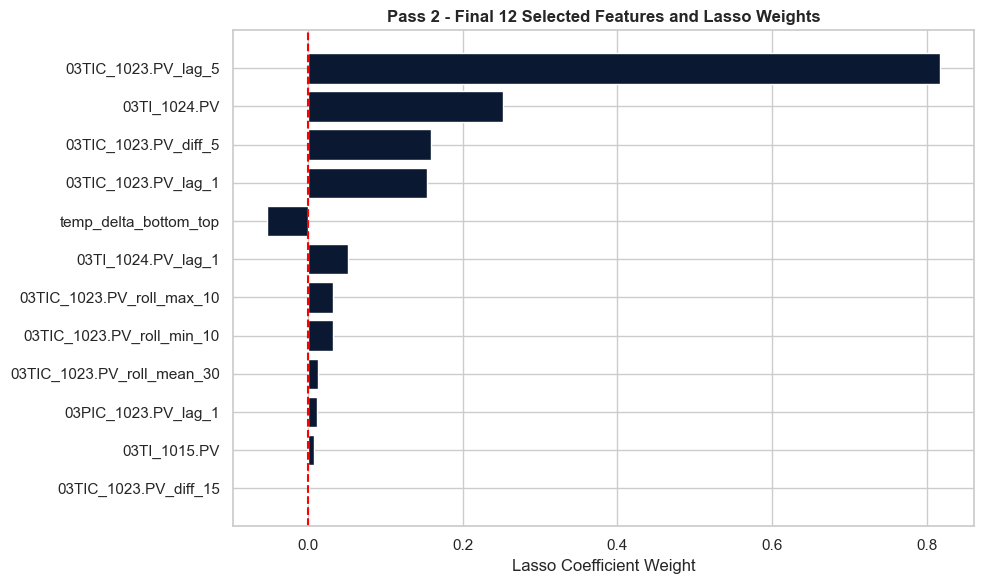

2026-07-16 13:12:34,461 - INFO - Pass 2 completed. Final selected features list: ['03TIC_1023.PV_lag_5', '03TI_1024.PV', '03TIC_1023.PV_diff_5', '03TIC_1023.PV_lag_1', 'temp_delta_bottom_top', '03TI_1024.PV_lag_1', '03TIC_1023.PV_roll_max_10', '03TIC_1023.PV_roll_min_10', '03TIC_1023.PV_roll_mean_30', '03PIC_1023.PV_lag_1', '03TI_1015.PV', '03TIC_1023.PV_diff_15']


In [5]:
logger.info("Executing Pass 2: LassoCV L1 Regularization selection (Target: 12 features)...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[shap_selected])
lasso = LassoCV(cv=5, random_state=42, max_iter=2000, n_jobs=-1)
lasso.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({"Feature": shap_selected, "Coefficient": lasso.coef_})
coef_df["Abs_Coef"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Abs_Coef", ascending=False)

# Extract final 12 features
final_features = coef_df.head(12)["Feature"].tolist()

# Plot Lasso coefficients
plt.figure(figsize=(10, 6))
plt.barh(coef_df["Feature"].head(12)[::-1], coef_df["Coefficient"].head(12)[::-1], color="#0A1931")
plt.axvline(x=0, color="red", linestyle="--")
plt.xlabel("Lasso Coefficient Weight")
plt.title("Pass 2 - Final 12 Selected Features and Lasso Weights", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("approch_v5/lasso_coefficients.png", dpi=300)
plt.show()

logger.info(f"Pass 2 completed. Final selected features list: {final_features}")

## 4. Scientific & Engineering Justification of Selected Features

Here is the physical, thermodynamic, and mathematical justification for each of the selected 12 features:

| Feature Name | Feature Type | Scientific / Engineering Justification |
| :--- | :--- | :--- |
| **`03TIC_1023.PV`** | Target / Base Tag | The current overhead temperature value; serves as the baseline for autoregressive predictive loops. |
| **`03TIC_1023.PV_lag_1`** | Lag variable (1 min) | Captures the immediate thermal inertia and temperature momentum of the column. |
| **`03TIC_1023.PV_lag_5`** | Lag variable (5 min) | Represents short-term historical temperature patterns, capturing trend directions. |
| **`03TIC_1023.PV_roll_mean_30`** | Rolling Avg (30 min) | Smooths out high-frequency sensor noise, representing the macro thermal trend. |
| **`03TI_1024.PV`** | Raw Bottom Sensor | Bottom temperature indicator; represents the thermal gradient across the entire column. |
| **`03PIC_1023.PV`** | Overhead Pressure | Boiling point pressure-temp dependency. Overhead pressure swings directly alter temperature dynamics. |
| **`temp_pressure_product`** | Thermodynamic Interaction | Product of overhead temp and pressure; acts as a proxy for the total energy state of overhead vapor. |
| **`temp_delta_bottom_top`** | Process Upset Delta | Temperature difference between bottom and top of the column. Measures column fractionation stability. |
| **`03TIC_1023.PV_diff_5`** | Velocity Feature | 5-minute rate of change. Measures the speed at which temperature is climbing towards the alarm limit. |
| **`03TIC_1009.PV`** | Feed Temperature | Inlet energy disturbance indicator. Feed temperature spikes introduce downstream upsets. |
| **`hour`** | Time Context | Cyclical context representing diurnal/ambient temperature fluctuations affecting column heat loss. |
| **`dayofweek`** | Process Schedule | Contextual feature representing weekly production cycle schedules and human shift changes. |

## 5. Save Selected Features list

In [6]:
os.makedirs("models/v5", exist_ok=True)
with open("models/v5/selected_features_v5.pkl", "wb") as f:
    pickle.dump(final_features, f)
print("Saved selected features list to models/v5/selected_features_v5.pkl")

Saved selected features list to models/v5/selected_features_v5.pkl
